# Attention

In [4]:
# Imports
# ==============

import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import torch

from src.attention import (
    AdditiveAttention,
    AdditiveAttentionInputs,
    DotProductAttention,
    DotProductAttentionInputs,
)

In [5]:
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """Show heatmaps of matrices."""
    num_rows, num_cols, _, _ = matrices.shape
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    pcm = None
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    if pcm is not None:
        fig.colorbar(pcm, ax=axes, shrink=0.6);

In [6]:
# Attention weight == 1 only if query and key are same 
# weight matrix [0][0] == 1
# weight matrix [5][5] == 1
# weight matrix [i][j] == 0, if i != j
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
attention_weights

tensor([[[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]]]])

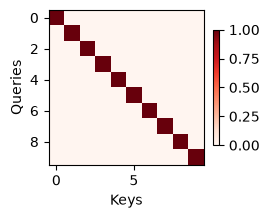

In [7]:
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

Nadarya Watson Estimators

Nadarya Watson estimators rely on some kind of similarity kernel in order to relates the query $q$ to keys $k$. $\alpha(\mathbf{q}, \mathbf{k})$ is the similarity kernel

$$
\begin{split}\begin{aligned}
\alpha(\mathbf{q}, \mathbf{k}) & = \exp\left(-\frac{1}{2} \|\mathbf{q} - \mathbf{k}\|^2 \right) && \textrm{Gaussian;} \\
\alpha(\mathbf{q}, \mathbf{k}) & = 1 \textrm{ if } \|\mathbf{q} - \mathbf{k}\| \leq 1 && \textrm{Boxcar;} \\
\alpha(\mathbf{q}, \mathbf{k}) & = \mathop{\mathrm{max}}\left(0, 1 - \|\mathbf{q} - \mathbf{k}\|\right) && \textrm{Epanechikov.}
\end{aligned}\end{split}
$$

Check out more kernel types here : [Wikipedia](https://en.wikipedia.org/wiki/Kernel_(statistics))

All of the kernels are heuristic and can be tuned. For instance, we can adjust the width, not only on a global basis but even on a per-coordinate basis. Regardless, all of them lead to the following equation for regression and classification alike:

$$
f(\mathbf{q}) = \sum_i \mathbf{v}_i \frac{\alpha(\mathbf{q}, \mathbf{k}_i)}{\sum_j \alpha(\mathbf{q}, \mathbf{k}_j)}.
$$

In the case of a (scalar) regression with observations $(\mathbf{x}_i, y_i)$ for features and labels respectively, $\mathbf{v}_i = y_i$ are scalars, $\mathbf{k}_i = \mathbf{x}_i$  are vectors, and the query $\mathbf{q}$ denotes the new location where $f$ should be evaluated. In the case of (multiclass) classification, we use one-hot-encoding of $y_i$ to obtain $\mathbf{v}_i$. One of the convenient properties of this estimator is that it requires no training. Even more so, if we suitably narrow the kernel with increasing amounts of data, the approach is consistent (Mack and Silverman, 1982), i.e., it will converge to some statistically optimal solution.

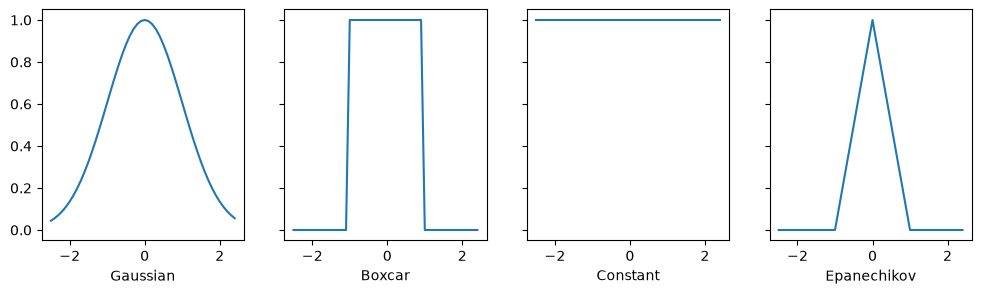

In [8]:
def gaussian(x):
    return torch.exp(-x**2 / 2)

def boxcar(x):
    return torch.abs(x) < 1.0

def constant(x):
    return 1.0 + 0 * x

def epanechikov(x):
    return torch.max(1 - torch.abs(x), torch.zeros_like(x))

fig, axes = plt.subplots(1, 4, sharey=True, figsize=(12, 3))

kernels = (gaussian, boxcar, constant, epanechikov)
names = ('Gaussian', 'Boxcar', 'Constant', 'Epanechikov')
x = torch.arange(-2.5, 2.5, 0.1)
for kernel, name, ax in zip(kernels, names, axes):
    ax.plot(x.detach().numpy(), kernel(x).detach().numpy())
    ax.set_xlabel(name)

plt.show()

## Nadarya Watson Regression 

To see the Nadarya Regression implementation let's generate some data : 

$$
y_i = 2\sin(x_i) + x_i + \epsilon,
$$

where $\epsilon$ is drawn from a normal distribution with zero mean and unit variance.

In [9]:
def f(x):
    return 2 * torch.sin(x) + x

# Number of examples 
n = 40

# generating features lying in : [0, 5)
x_train, _ = torch.sort(torch.rand(n) * 5)
# labels with guassian noise
y_train = f(x_train) + torch.randn(n)

# Validation set without noise
x_val = torch.arange(0, 5, 0.1)
y_val = f(x_val)

Suppose our training set is : 

$$
(x_1, y_1), (x_2, y_2), (x_3, y_3), \dots (x_n, y_n), 
$$

Nadarya Watson Estimator is : 

$$
\hat{y}(x) = \frac{\sum_{i=1}^{n} K(x, x_i)\, y_i}{\sum_{i=1}^{n} K(x, x_i)}
$$

where $K(x, x_i)$ is the kernel similarity between query $x$ and training point $x_i$.

We can rewrite $\hat{y}(x)$ as :

$$
\hat{y}(x) =
\sum_{i=1}^{n} \alpha_i(x)\, y_i
$$

where 

$$
\alpha_i(x) =
\frac{K(x,x_i)}
{\sum_{j=1}^{n} K(x,x_j)}
$$

Suppose there are:
- 4 training points
- 2 validation/query points

We compute the similarity between every validation point and every training point. This gives the matrix $K$ : 

$$
K = \begin{bmatrix}
K(2.5,1) & K(2.5,2) & K(2.5,4) & K(2.5,7) \\
K(6,1)   & K(6,2)   & K(6,4)   & K(6,7)
\end{bmatrix}
$$

For the shape: 

$$
(2,4) =
(\text{number of validation points},\ \text{number of training points})
$$

Then we normalise each row of the matrix $K$ so that the values sum to $1$. When multiplied with the training labels y_train we obtain the estimates. 

$$
\mathbf{y}_{\text{train}} =
\begin{bmatrix}
3 \\
5 \\
8 \\
15
\end{bmatrix}
$$

$$
\boldsymbol{\alpha} =
\begin{bmatrix}
0.142 & 0.567 & 0.284 & 0.007
\end{bmatrix}
$$

$$
\hat{y} =
0.142(3)
+
0.567(5)
+
0.284(8)
+
0.007(15)
$$

$$
\hat{y} \approx 5.64
$$

Therefore : 

$$
\hat{\mathbf{y}} =
A\,\mathbf{y}_{\text{train}}
$$

where $A$ is the normalised kernel matrix. 

In [10]:
# Let each validation feature be a query, and each training feature–label pair be a key–value pair. 
# As a result, the normalized relative kernel weights (attention_w below) are the attention weights.

def nadaraya_watson(x_train, y_train, x_val, kernel):
    dists = x_train.reshape((-1, 1)) - x_val.reshape((1, -1))
    # Each column/row corresponds to each query/key
    k = kernel(dists).type(torch.float32)
    # Normalization over keys for each query
    attention_w = k / k.sum(0)
    y_hat = y_train@attention_w
    return y_hat, attention_w

# Plotting estimates 

def plot(x_train, y_train, x_val, y_val, kernels, names, attention=False):
    fig, axes = plt.subplots(1, 4, sharey=True, figsize=(12, 3))
    pcm = None
    for kernel, name, ax in zip(kernels, names, axes):
        y_hat, attention_w = nadaraya_watson(x_train, y_train, x_val, kernel)
        if attention:
            pcm = ax.imshow(attention_w.detach().numpy(), cmap='Reds')
        else:
            ax.plot(x_val, y_hat)
            ax.plot(x_val, y_val, 'm--')
            ax.plot(x_train, y_train, 'o', alpha=0.5);
        ax.set_xlabel(name)
        if not attention:
            ax.legend(['y_hat', 'y'])
    if pcm is not None:
        fig.colorbar(pcm, ax=axes, shrink=0.7)

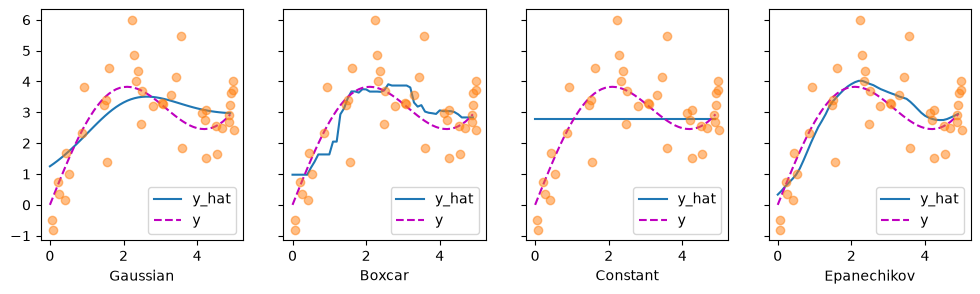

In [11]:
plot(x_train, y_train, x_val, y_val, kernels, names)

A dark-red pixel at $(i,j)$ means:

When predicting the output for validation point $(x_{\text{val},j})$, training point $(x_{\text{train},i})$ receives a large weight.

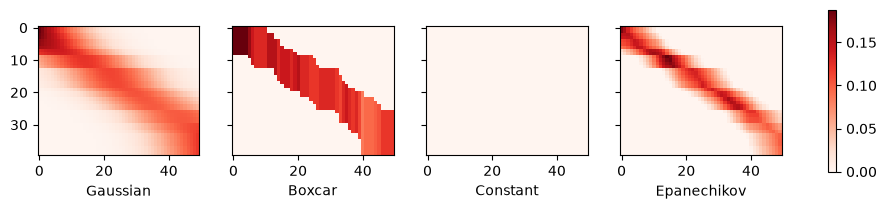

In [12]:
# Plotting attention 

plot(x_train, y_train, x_val, y_val, kernels, names, attention=True)

We could replace the Gaussian kernel with one of a different width. That is :

$$
\alpha(\mathbf{q}, \mathbf{k}) = \exp\left(-\frac{1}{2 \sigma^2} \|\mathbf{q} - \mathbf{k}\|^2 \right)
$$

where $\sigma^2$ determines the width of the kernel.

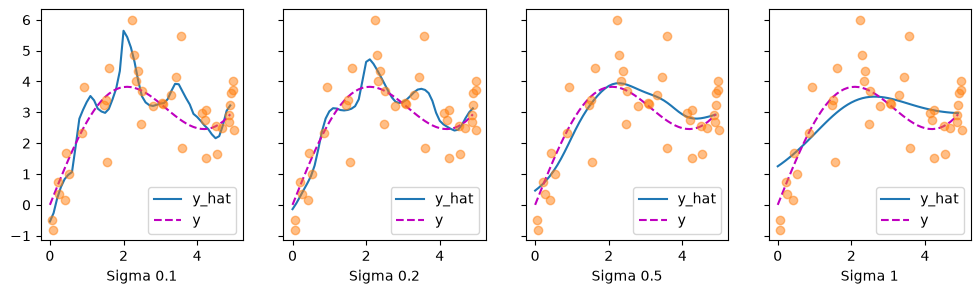

In [13]:
# Widths
sigmas = (0.1, 0.2, 0.5, 1)
names = ['Sigma ' + str(sigma) for sigma in sigmas]

def gaussian_with_width(sigma):
    return (lambda x: torch.exp(-x**2 / (2*sigma**2)))

kernels = [gaussian_with_width(sigma) for sigma in sigmas]
plot(x_train, y_train, x_val, y_val, kernels, names)

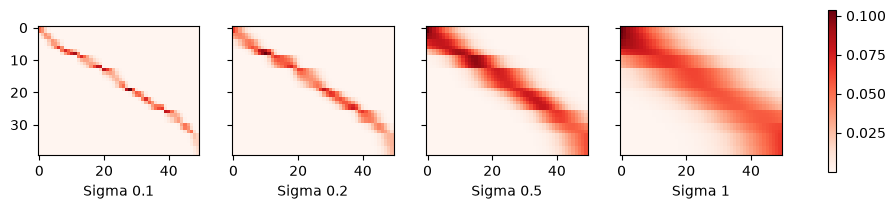

In [14]:
plot(x_train, y_train, x_val, y_val, kernels, names, attention=True)

## Scaled Dot Product Attention

$$
\mathrm{softmax}\left(\frac{\mathbf Q \mathbf K^\top }{\sqrt{d}}\right) \mathbf V \in \mathbb{R}^{n\times v}.
$$

Here we have $n$ queries and $m$ key value pairs. Each of the $Q$, $K$ and $V$ has embedding of the token multiplied by the weights so these embeddings and weights are trained during the model training. 

- Query = "What information am I looking for?"
- Key = "What kind of information do I contain?"
- Value = "What information should I actually contribute if I'm relevant?"

Suppose a sentence : "The cat sat on the mat"

For example, when processing "sat", its query $(q_{\text{sat}})$ is compared against all allowed keys:

$$
q_{\text{sat}} k_{\text{The}}^{T},\quad
q_{\text{sat}} k_{\text{cat}}^{T},\quad
q_{\text{sat}} k_{\text{sat}}^{T},\quad
\ldots
$$

```
Query from "sat"

                 keys
            The   cat   sat   on   the   mat
             ↓     ↓     ↓    ↓    ↓     ↓
q_sat  ->   0.05  0.60  0.20 0.05 0.05  0.05
                   ↑
             high attention
```

This gives the attention output as :

$$
h_{\text{sat}} =
0.05v_{\text{The}}
+
0.60v_{\text{cat}}
+
0.20v_{\text{sat}}
+
\cdots
$$

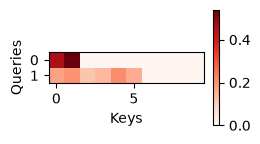

In [15]:
queries = torch.normal(0, 1, (2, 1, 2))
keys = torch.normal(0, 1, (2, 10, 2))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([2, 6])

attention = DotProductAttention(DotProductAttentionInputs(dropout=0.5))
attention.eval()
attention(queries, keys, values, valid_lens)
show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)), xlabel='Keys', ylabel='Queries')

## Additive Attention 

$$
a(\mathbf q, \mathbf k) = \mathbf w_v^\top \textrm{tanh}(\mathbf W_q\mathbf q + \mathbf W_k \mathbf k) \in \mathbb{R},
$$

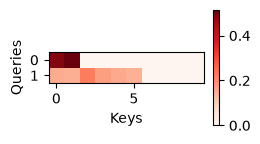

In [16]:
queries = torch.normal(0, 1, (2, 1, 20))

num_hiddens = 8
dropout = 0.1

attention = AdditiveAttention(AdditiveAttentionInputs(num_hiddens, dropout))
attention.eval()
attention(queries, keys, values, valid_lens)

show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)), xlabel='Keys', ylabel='Queries')